## 3. Melakukan Klasifikasi LDA

## 3. Melakukan klasifikasi LDA

1. Import Library

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from gensim import corpora
from gensim.models.ldamodel import LdaModel
from gensim.models import CoherenceModel
import seaborn as sns

2. Membaca Dataset

In [ ]:
# Baca dataset
df = pd.read_csv('kompas_articles_new.csv')

# Atur agar Pandas menampilkan semua baris
pd.set_option('display.max_rows', None)
print("Jumlah total berita:", len(df))

# Tampilkan semua isi dataframe
display(df)

Jumlah total berita: 128


,Judul,Isi (100 kata),Kategori,URL,Status
0,Jokowi Kenakan Pakaian Adat Betawi di Sidang T...,"JAKARTA, KOMPAS.com- Presiden Joko Widodo mema...",Nasional,https://nasional.kompas.com/read/2024/08/16/11...,Sukses
1,KPU Tegaskan Pemilih Tak Terdaftar di DPT Bisa...,"JAKARTA, KOMPAS.com- Komisi Pemilihan Umum (KP...",Nasional,https://nasional.kompas.com/read/2024/02/13/21...,Sukses
2,Warga Sebut Ada Benda Serupa Jimat pada Mayat ...,"TANGERANG SELATAN, KOMPAS.com- Seutas tali ber...",Megapolitan,https://megapolitan.kompas.com/read/2024/05/11...,Sukses
3,Polisi Menganiaya Mereka yang Cinta Damai dan ...,"JAKARTA, KOMPAS.com- Sejumlah massa mendapat k...",Megapolitan,https://megapolitan.kompas.com/read/2024/08/26...,Sukses
4,"Airlangga Hartarto Mundur dari Ketum, Golkar B...","JAKARTA, KOMPAS.com- Airlangga Hartarto secara...",Nasional,https://nasional.kompas.com/read/2024/08/12/08...,Sukses
5,Nasdem Pastikan Dukung Ilham Habibie untuk Pil...,"JAKARTA, KOMPAS.com- Partai Nasdem memastikan ...",Nasional,https://nasional.kompas.com/read/2024/07/29/17...,Sukses
6,"""Influencer Parenting"" Aniaya Balita, Kriminol...","JAKARTA, KOMPAS.com -Kriminolog Universitas In...",Megapolitan,https://megapolitan.kompas.com/read/2024/08/02...,Sukses
7,Jalan Mulus Bahlil Raih Kursi Ketum Golkar,"JAKARTA, KOMPAS.com- Jalan Menteri Energi dan ...",Nasional,https://nasional.kompas.com/read/2024/08/21/05...,Sukses
8,"Maruarar Sirait Dukung Prabowo-Gibran, TKN: Ma...","JAKARTA, KOMPAS.com- Sekretaris Tim Kampanye N...",Nasional,https://nasional.kompas.com/read/2024/01/19/22...,Sukses
9,"Usai Diturap, Kali Mati di Pademangan Tak Lagi...","JAKARTA, KOMPAS.com- Usai diturap, Kali Mati y...",Megapolitan,https://megapolitan.kompas.com/read/2024/08/12...,Sukses


3. Preprocessing Data

In [ ]:
def preprocess_data(df, source_col="Isi (100 kata)"):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    stop_factory = StopWordRemoverFactory()
    stopwords = set(stop_factory.get_stop_words())

    clean_texts = []
    for text in df[source_col].fillna("").astype(str):
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', '', text)
        tokens = text.split()
        tokens = [t for t in tokens if t not in stopwords and len(t) > 1]
        stemmed = [stemmer.stem(t) for t in tokens]
        clean_texts.append(" ".join(stemmed))
    df["clean"] = clean_texts
    return df

df_clean = preprocess_data(df)
display(df_clean.head())

,Judul,Isi (100 kata),Kategori,URL,Status,clean
0,Jokowi Kenakan Pakaian Adat Betawi di Sidang T...,"JAKARTA, KOMPAS.com- Presiden Joko Widodo mema...",Nasional,https://nasional.kompas.com/read/2024/08/16/11...,Sukses,jakarta kompascom presiden joko widodo pakai b...
1,KPU Tegaskan Pemilih Tak Terdaftar di DPT Bisa...,"JAKARTA, KOMPAS.com- Komisi Pemilihan Umum (KP...",Nasional,https://nasional.kompas.com/read/2024/02/13/21...,Sukses,jakarta kompascom komisi pilih umum kpu ri pas...
2,Warga Sebut Ada Benda Serupa Jimat pada Mayat ...,"TANGERANG SELATAN, KOMPAS.com- Seutas tali ber...",Megapolitan,https://megapolitan.kompas.com/read/2024/05/11...,Sukses,tangerang selatan kompascom utas tali warna hi...
3,Polisi Menganiaya Mereka yang Cinta Damai dan ...,"JAKARTA, KOMPAS.com- Sejumlah massa mendapat k...",Megapolitan,https://megapolitan.kompas.com/read/2024/08/26...,Sukses,jakarta kompascom jumlah massa dapat keras apa...
4,"Airlangga Hartarto Mundur dari Ketum, Golkar B...","JAKARTA, KOMPAS.com- Airlangga Hartarto secara...",Nasional,https://nasional.kompas.com/read/2024/08/12/08...,Sukses,jakarta kompascom airlangga hartarto resmi und...


4. Tokenisasi, Dictionary, dan Corpus

In [ ]:
texts = [doc.split() for doc in df_clean["clean"]]
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=2, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in texts]

5. Menentukan Model LDA Terbaik (dengan Coherence Score)

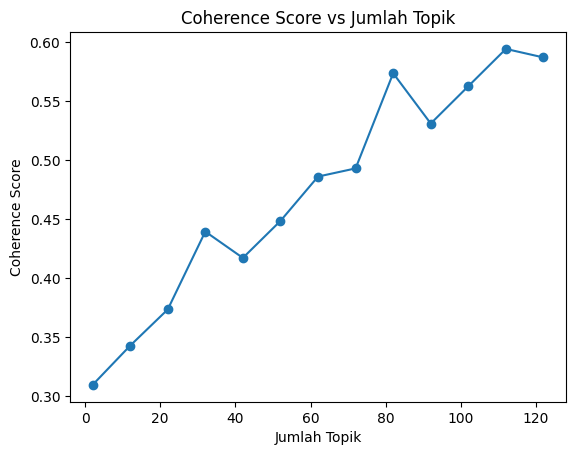

✅ Model terbaik memiliki 112 topik
Coherence Score terbaik: 0.5944232145404877


In [ ]:
coherence_values = []
model_list = []
topic_range = range(2, 130, 10)

for num_topics in topic_range:
    model = LdaModel(
        corpus=corpus,
        num_topics=num_topics,
        id2word=dictionary,
        random_state=42,
        passes=10,
        iterations=100
    )
    model_list.append(model)
    coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherencemodel.get_coherence())

# Visualisasi Coherence Score
plt.plot(topic_range, coherence_values, marker='o')
plt.xlabel("Jumlah Topik")
plt.ylabel("Coherence Score")
plt.title("Coherence Score vs Jumlah Topik")
plt.show()

# Model terbaik
optimal_model = model_list[coherence_values.index(max(coherence_values))]
optimal_topics = topic_range[coherence_values.index(max(coherence_values))]
print("✅ Model terbaik memiliki", optimal_topics, "topik")
print("Coherence Score terbaik:", max(coherence_values))

6. Melakukan Topik yang terbaik

In [ ]:
for idx, topic in optimal_model.print_topics(-1):
    print(f"\nTopik {idx+1}: {topic}")


Topik 1: 0.067*"rumah" + 0.067*"baswedan" + 0.050*"tempat" + 0.050*"bagi" + 0.033*"satu" + 0.033*"atas" + 0.033*"anies" + 0.033*"sembunyi" + 0.033*"nomor" + 0.033*"salah"

Topik 2: 0.001*"tni" + 0.001*"pilkada" + 0.001*"kepala" + 0.001*"pilih" + 0.001*"bambang" + 0.001*"tetap" + 0.001*"adu" + 0.001*"kan" + 0.001*"militer" + 0.001*"kok"

Topik 3: 0.038*"pramono" + 0.038*"gubernur" + 0.031*"sehat" + 0.031*"periksa" + 0.030*"kader" + 0.029*"partai" + 0.021*"aku" + 0.021*"calon" + 0.021*"usung" + 0.019*"jadi"

Topik 4: 0.034*"belanja" + 0.034*"layan" + 0.034*"bpom" + 0.025*"daerah" + 0.025*"laku" + 0.017*"publik" + 0.017*"kantor" + 0.017*"segera" + 0.017*"persen" + 0.017*"lihat"

Topik 5: 0.001*"warga" + 0.001*"tanding" + 0.001*"dki" + 0.001*"bangun" + 0.001*"pemprov" + 0.001*"bola" + 0.001*"dprd" + 0.001*"tahu" + 0.001*"anggar" + 0.001*"internasional"

Topik 6: 0.035*"pdip" + 0.028*"jamin" + 0.028*"ketua" + 0.028*"megawati" + 0.028*"rakyat" + 0.021*"hukum" + 0.021*"metro" + 0.021*"polda"

7. Menentukan Topik Dominan per Dokumen

In [ ]:
dominant_topics = []
for i, doc_bow in enumerate(corpus):
    topics_in_doc = optimal_model.get_document_topics(doc_bow, minimum_probability=0)
    topics_in_doc = sorted(topics_in_doc, key=lambda x: x[1], reverse=True)
    topic_num, prop = topics_in_doc[0]
    dominant_topics.append((i, topic_num + 1, round(prop, 3)))

df_dominant = pd.DataFrame(dominant_topics, columns=["Index", "Topik Dominan", "Proporsi"])
df_result = pd.concat([df_clean.reset_index(drop=True), df_dominant.set_index("Index")], axis=1)

display(df_result[["Judul", "Kategori", "Topik Dominan", "Proporsi", "clean"]])

,Judul,Kategori,Topik Dominan,Proporsi,clean
0,Jokowi Kenakan Pakaian Adat Betawi di Sidang T...,Nasional,69,0.983,jakarta kompascom presiden joko widodo pakai b...
1,KPU Tegaskan Pemilih Tak Terdaftar di DPT Bisa...,Nasional,89,0.981,jakarta kompascom komisi pilih umum kpu ri pas...
2,Warga Sebut Ada Benda Serupa Jimat pada Mayat ...,Megapolitan,77,0.982,tangerang selatan kompascom utas tali warna hi...
3,Polisi Menganiaya Mereka yang Cinta Damai dan ...,Megapolitan,24,0.984,jakarta kompascom jumlah massa dapat keras apa...
4,"Airlangga Hartarto Mundur dari Ketum, Golkar B...",Nasional,44,0.982,jakarta kompascom airlangga hartarto resmi und...
5,Nasdem Pastikan Dukung Ilham Habibie untuk Pil...,Nasional,35,0.984,jakarta kompascom partai nasdem pasti dukung i...
6,"""Influencer Parenting"" Aniaya Balita, Kriminol...",Megapolitan,75,0.981,jakarta kompascom kriminolog universitas indon...
7,Jalan Mulus Bahlil Raih Kursi Ketum Golkar,Nasional,21,0.986,jakarta kompascom jalan menteri energi sumber ...
8,"Maruarar Sirait Dukung Prabowo-Gibran, TKN: Ma...",Nasional,51,0.610,jakarta kompascom sekretaris tim kampanye nasi...
9,"Usai Diturap, Kali Mati di Pademangan Tak Lagi...",Megapolitan,99,0.980,jakarta kompascom usai turap kali mati banyak ...


8. Visualisasi Distribusi Topik per Dokumen

# --- Versi Bar Chart ---

/tmp/ipython-input-2308262128.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


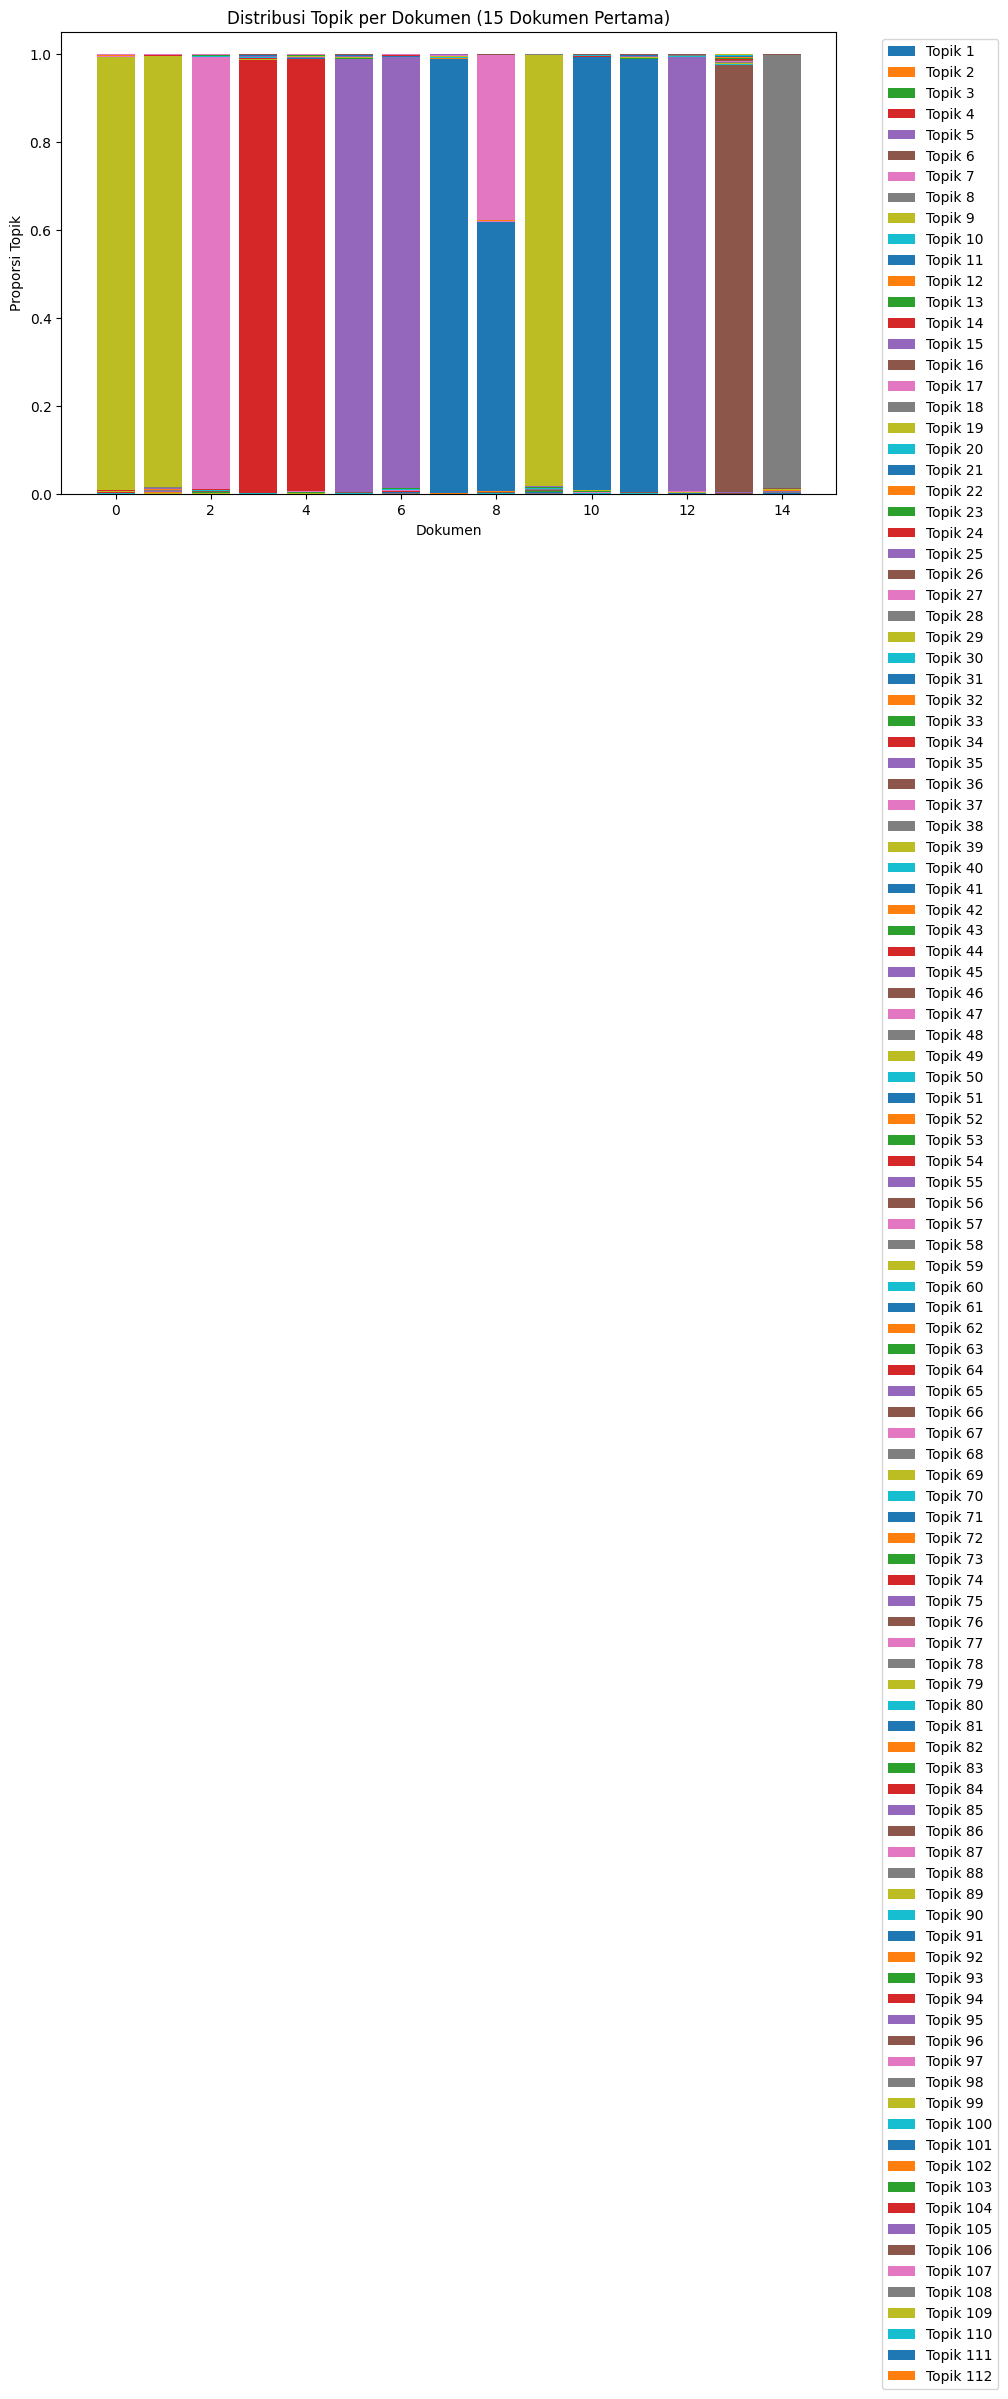

In [ ]:
# Ambil distribusi topik untuk setiap dokumen
topic_distribution = [optimal_model.get_document_topics(doc, minimum_probability=0) for doc in corpus]

# Batasi ke 15 dokumen pertama agar tidak padat
n_docs = 15
data = np.array([[prob for _, prob in topic_distribution[i]] for i in range(n_docs)])

# Plot stacked bar
fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(n_docs)

for k in range(data.shape[1]):
    ax.bar(range(n_docs), data[:, k], bottom=bottom, label=f'Topik {k+1}')
    bottom += data[:, k]

ax.set_title("Distribusi Topik per Dokumen (15 Dokumen Pertama)")
ax.set_xlabel("Dokumen")
ax.set_ylabel("Proporsi Topik")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# --- Versi Heatmap ---

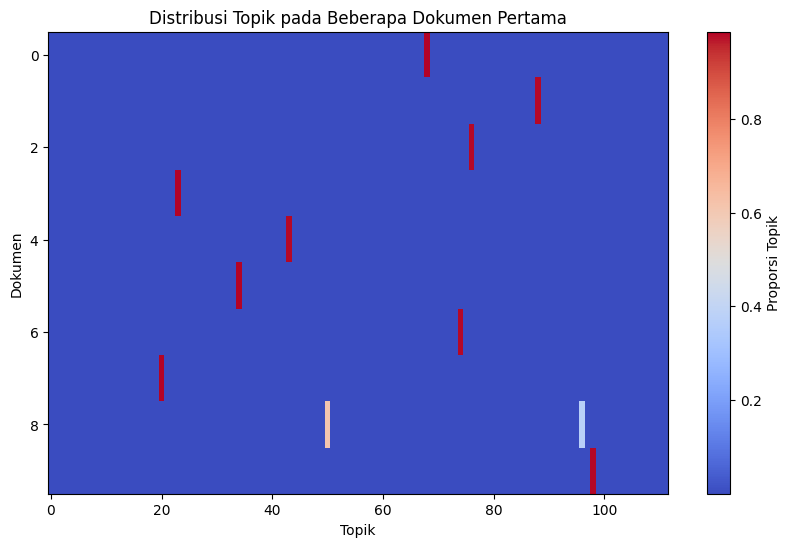

In [ ]:
topic_distribution = [optimal_model.get_document_topics(doc, minimum_probability=0) for doc in corpus]

num_docs_to_show = 10
topic_matrix = np.array([[score for _, score in doc] for doc in topic_distribution[:num_docs_to_show]])

plt.figure(figsize=(10, 6))
plt.imshow(topic_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Proporsi Topik')
plt.xlabel('Topik')
plt.ylabel('Dokumen')
plt.title('Distribusi Topik pada Beberapa Dokumen Pertama')
plt.show()

8. Menyiapkan Data untuk Klasifikasi (TF-IDF)

In [ ]:
X = df_result["clean"]
y = df_result["Kategori"]

vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

9. Klasifikasi: SVM & Softmax Regression

In [ ]:
# SVM
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Softmax Regression
softmax_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
softmax_model.fit(X_train, y_train)
y_pred_softmax = softmax_model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


## Fungsi Evaluasi

In [ ]:
def evaluasi_model(y_true, y_pred, model_name):
    print(f"\n=== Evaluasi Model: {model_name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Langkah 1 — Evaluasi Model SVM

### 🔍 Evaluasi Model SVM ###

=== Evaluasi Model: SVM ===
Accuracy : 0.8846153846153846
Precision: 0.902834008097166
Recall   : 0.8846153846153846

Classification Report:
               precision    recall  f1-score   support

 Megapolitan       1.00      0.70      0.82        10
    Nasional       0.84      1.00      0.91        16

    accuracy                           0.88        26
   macro avg       0.92      0.85      0.87        26
weighted avg       0.90      0.88      0.88        26



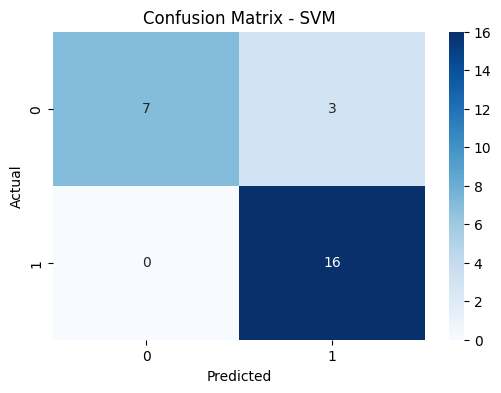

In [ ]:
print("### 🔍 Evaluasi Model SVM ###")
evaluasi_model(y_test, y_pred_svm, "SVM")

Langkah 2 — Evaluasi Model Softmax Regression



### 🔍 Evaluasi Model Softmax Regression ###

=== Evaluasi Model: Softmax Regression ===
Accuracy : 0.6538461538461539
Precision: 0.7784615384615385
Recall   : 0.6538461538461539

Classification Report:
               precision    recall  f1-score   support

 Megapolitan       1.00      0.10      0.18        10
    Nasional       0.64      1.00      0.78        16

    accuracy                           0.65        26
   macro avg       0.82      0.55      0.48        26
weighted avg       0.78      0.65      0.55        26



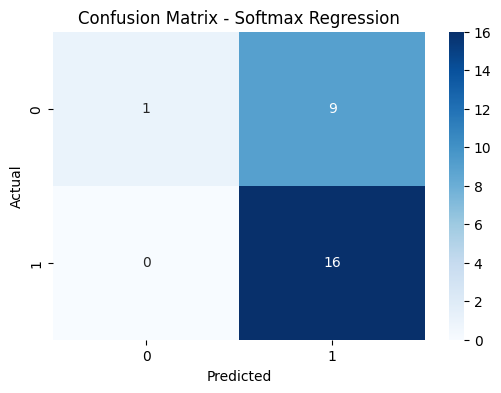

In [ ]:
print("\n\n### 🔍 Evaluasi Model Softmax Regression ###")
evaluasi_model(y_test, y_pred_softmax, "Softmax Regression")

10. Menghitung Coherence Score Akhir

In [ ]:
coherence_model = CoherenceModel(model=optimal_model, texts=texts, dictionary=dictionary, coherence='c_v')
coherence = coherence_model.get_coherence()
print("✅ Coherence Score (c_v) untuk model terbaik:", coherence)

✅ Coherence Score (c_v) untuk model terbaik: 0.5944232145404877
